In [11]:
pip install timm

Note: you may need to restart the kernel to use updated packages.


In [12]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

input_dir = r"C:\Users\xiaoh\OneDrive\Desktop\Final_morphogenesis\05_shared_data\input"
output_dir = r"C:\Users\xiaoh\OneDrive\Desktop\Final_morphogenesis\09_experiments\previous_tests\02_structural_resonance\output\ice_crystal_01\attention_maps"


os.makedirs(input_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)

video_path = os.path.join(input_dir, "ice_crystal_01_resized.mp4")

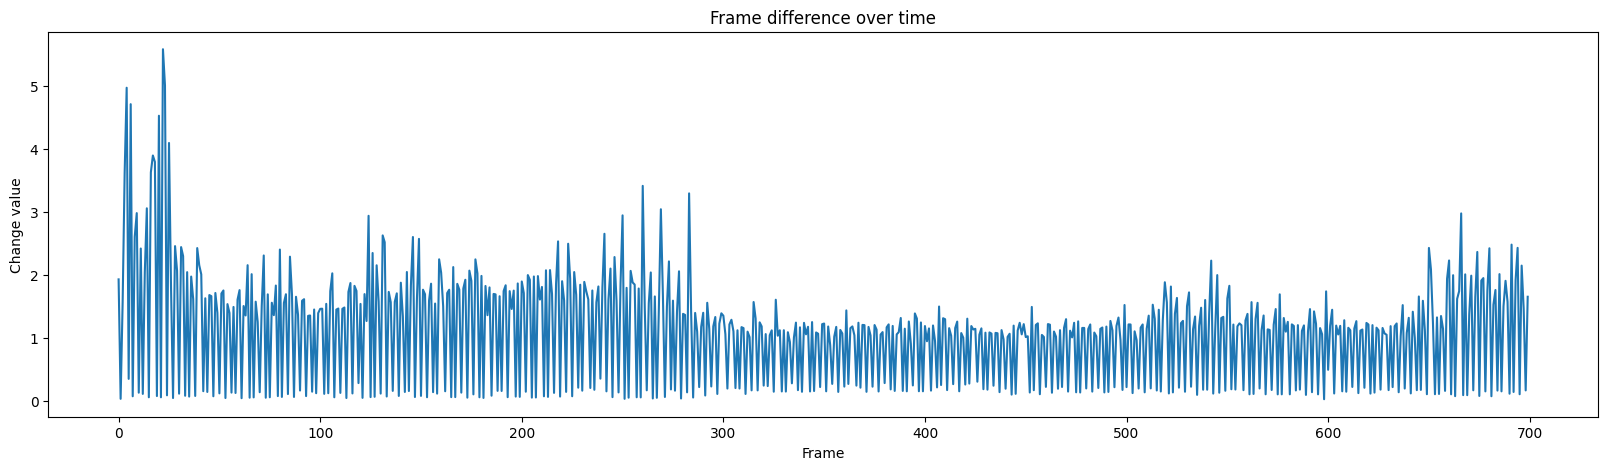

最大变化值: 5.59
平均变化值: 1.08


In [13]:


cap = cv2.VideoCapture(video_path)
ret, prev_frame = cap.read()
prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

changes = []
frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_count += 1
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    diff = cv2.absdiff(prev_gray, gray)
    changes.append(np.mean(diff))
    prev_gray = gray

cap.release()

plt.figure(figsize=(20, 5))
plt.plot(changes)
plt.xlabel('Frame')
plt.ylabel('Change value')
plt.title('Frame difference over time')
plt.show()

print(f"最大变化值: {max(changes):.2f}")
print(f"平均变化值: {sum(changes)/len(changes):.2f}")


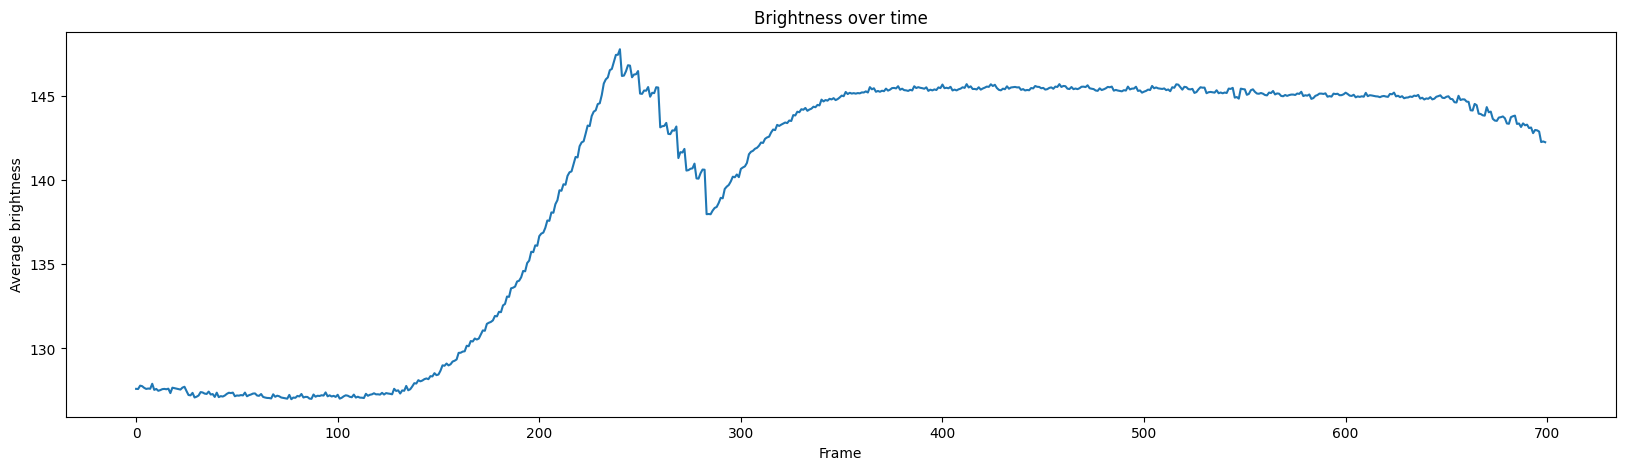

In [14]:
cap = cv2.VideoCapture(video_path)
ret, first_frame = cap.read()
first_gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)

brightness = []
frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_count += 1
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    brightness.append(np.mean(gray))

cap.release()

plt.figure(figsize=(20, 5))
plt.plot(brightness)
plt.xlabel('Frame')
plt.ylabel('Average brightness')
plt.title('Brightness over time')
plt.show()

结晶开始: 第 140 帧


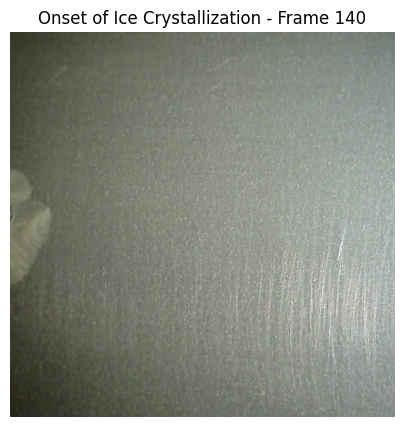

亮度最高帧: 240


In [23]:
brightness = np.array(brightness)
start = None

for i in range(10, len(brightness)):
    if brightness[i] - brightness[i-10] > 0.5:
        start = i
        break

print(f"结晶开始: 第 {start} 帧")

cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, start)
ret, start_frame = cap.read()
cap.release()

plt.figure(figsize=(8,5))
plt.imshow(cv2.cvtColor(start_frame, cv2.COLOR_BGR2RGB))
plt.title(f'Onset of Ice Crystallization - Frame {start}')
plt.axis('off')
plt.show()
peak = int(np.argmax(brightness))
print(f"亮度最高帧: {peak}")

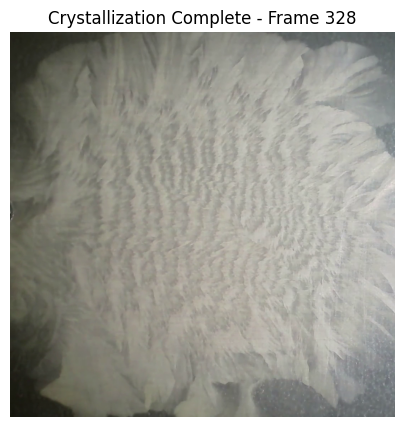

结晶完成: 第 328 帧


In [16]:
# 找亮度变化小于某个值的第一帧，就是稳定开始的地方
stable = None
window = 20  # 看前后20帧的变化

for i in range(peak, len(brightness) - window):
    if np.std(brightness[i:i+window]) < 0.3:
        stable = i
        break

cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, stable)
ret, stable_frame = cap.read()
cap.release()

plt.figure(figsize=(8,5))
plt.imshow(cv2.cvtColor(stable_frame, cv2.COLOR_BGR2RGB))
plt.title(f'Crystallization Complete - Frame {stable}')
plt.axis('off')
plt.show()

print(f"结晶完成: 第 {stable} 帧")

# DINO Attention Map

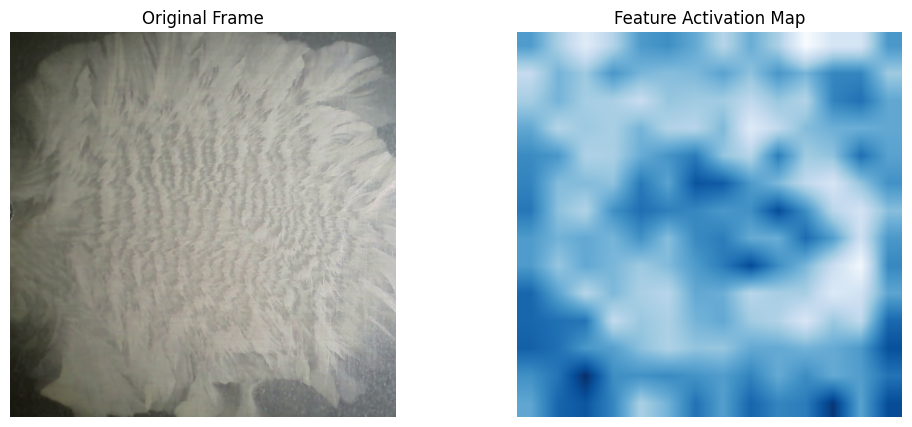

In [17]:
import torch
import timm
from PIL import Image
import torchvision.transforms as transforms

model = timm.create_model('vit_base_patch16_224.dino', pretrained=True)
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, stable)
ret, frame = cap.read()
cap.release()

img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
tensor = transform(img).unsqueeze(0)

with torch.no_grad():
    features = model.forward_features(tensor)

patch_features = features[0, 1:, :]
attn_weights = patch_features.norm(dim=-1).reshape(14, 14).numpy()
h, w = frame.shape[:2]
attn_resized = cv2.resize(attn_weights, (w, h))
attn_norm = (attn_resized - attn_resized.min()) / (attn_resized.max() - attn_resized.min())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Frame')
axes[0].axis('off')
axes[1].imshow(attn_norm, cmap='Blues')
axes[1].set_title('Feature Activation Map')
axes[1].axis('off')
plt.savefig(os.path.join(output_dir, "attention_map.png"), dpi=150, bbox_inches='tight')
plt.show()

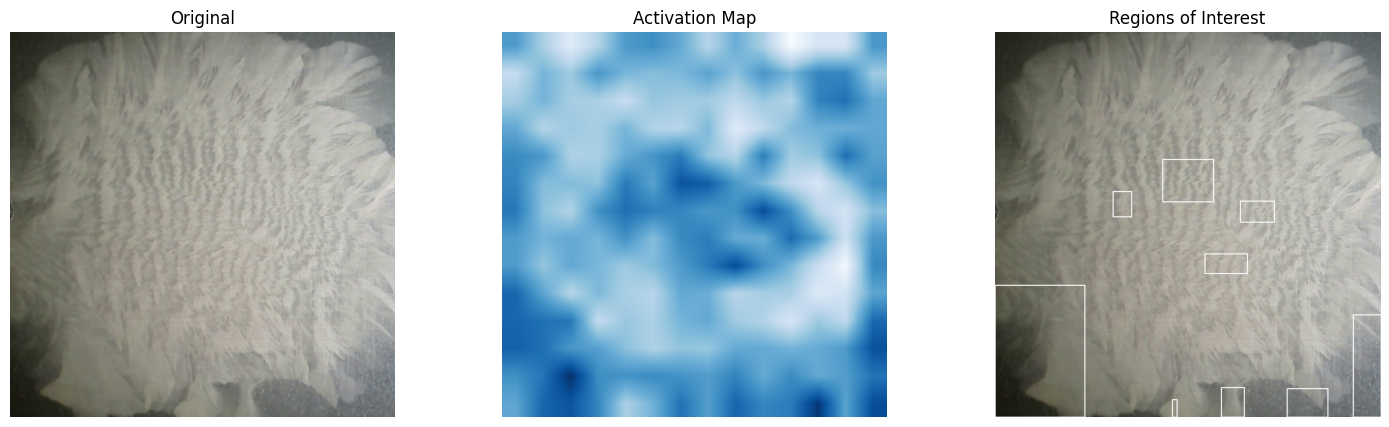

In [18]:
# 把activation map转成uint8
attn_uint8 = (attn_norm * 255).astype(np.uint8)

# 找最亮区域的轮廓
_, thresh = cv2.threshold(attn_uint8, 185, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 在原图上画出感兴趣区域
frame_marked = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB).copy()
for cnt in contours:
    if cv2.contourArea(cnt) > 500:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(frame_marked, (x, y), (x+w, y+h), (255, 255, 255), 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(attn_norm, cmap='Blues')
axes[1].set_title('Activation Map')
axes[1].axis('off')
axes[2].imshow(frame_marked)
axes[2].set_title('Regions of Interest')
axes[2].axis('off')
plt.savefig(os.path.join(output_dir, "blob_tracking.png"), dpi=150, bbox_inches='tight')
plt.show()

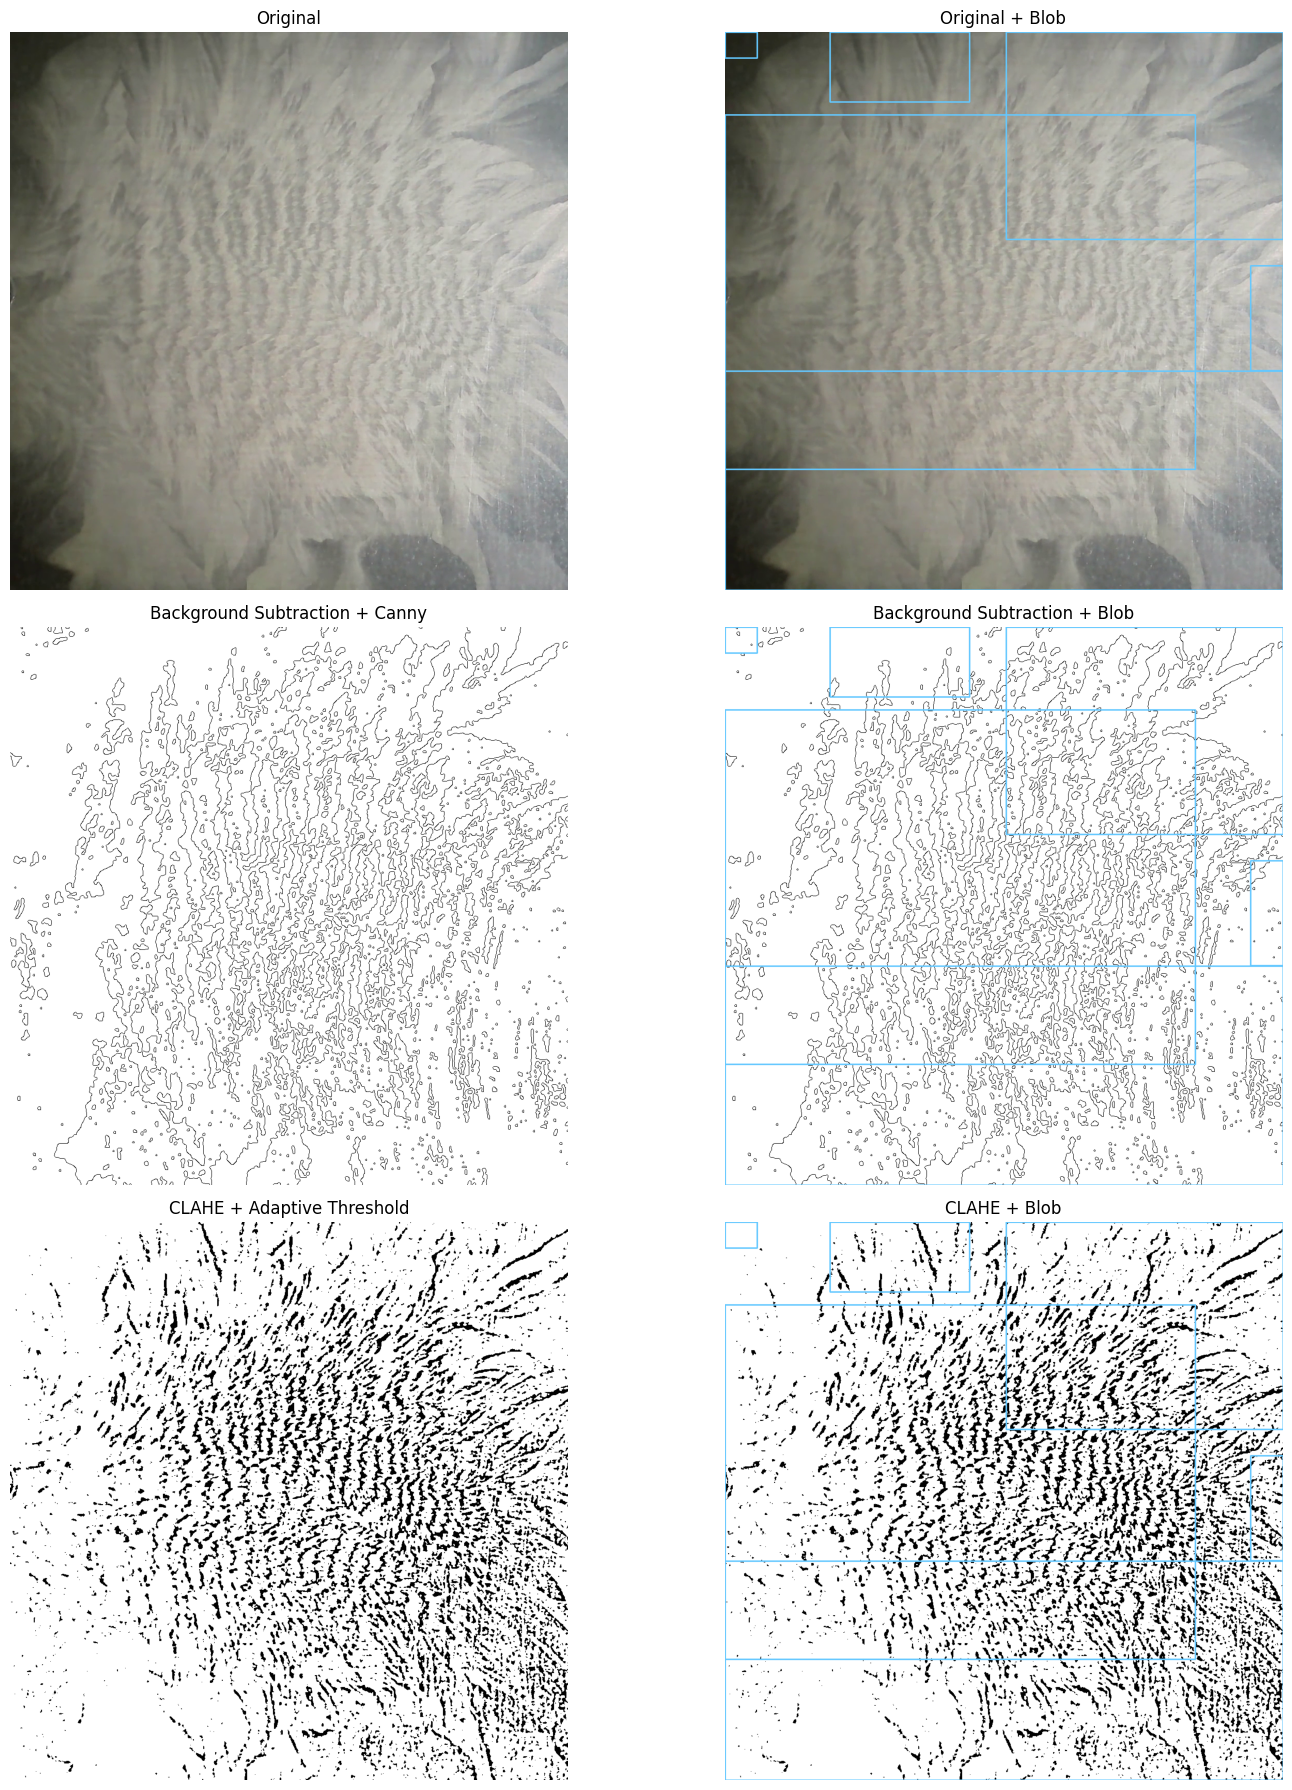

In [19]:
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 3)
ret_bg, bg_frame = cap.read()
cap.set(cv2.CAP_PROP_POS_FRAMES, 400)
ret, frame = cap.read()
cap.release()

bg_gray = cv2.cvtColor(bg_frame, cv2.COLOR_BGR2GRAY)
bg_blur = cv2.GaussianBlur(bg_gray, (5,5), 0)
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Method 1
blur1 = cv2.GaussianBlur(gray, (5,5), 0)
diff = cv2.absdiff(bg_blur, blur1)
_, thresh1 = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)
kernel = np.ones((3,3), np.uint8)
thresh1 = cv2.morphologyEx(thresh1, cv2.MORPH_OPEN, kernel)
thresh1 = cv2.morphologyEx(thresh1, cv2.MORPH_CLOSE, kernel)
edges = cv2.Canny(thresh1, 10, 50)
method1 = cv2.bitwise_not(edges)

# Method 2
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
enhanced = clahe.apply(gray)
blur2 = cv2.GaussianBlur(enhanced, (3,3), 0)
method2 = cv2.adaptiveThreshold(blur2, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 21, 8)
kernel2 = np.ones((2,2), np.uint8)
method2 = cv2.morphologyEx(method2, cv2.MORPH_OPEN, kernel2)

# 只对原图跑一次attention map
img = Image.fromarray(frame_rgb)
tensor = transform(img).unsqueeze(0)
with torch.no_grad():
    features = model.forward_features(tensor)
patch_features = features[0, 1:, :]
attn_weights = patch_features.norm(dim=-1).reshape(14, 14).numpy()
h, w = frame.shape[:2]
attn_resized = cv2.resize(attn_weights, (w, h))
attn_norm = (attn_resized - attn_resized.min()) / (attn_resized.max() - attn_resized.min())
attn_uint8 = (attn_norm * 255).astype(np.uint8)
_, thresh_blob = cv2.threshold(attn_uint8, 120, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(thresh_blob, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

def draw_blobs(image_rgb):
    result = image_rgb.copy()
    for cnt in contours:
        if cv2.contourArea(cnt) > 500:
            x, y, bw, bh = cv2.boundingRect(cnt)
            cv2.rectangle(result, (x, y), (x+bw, y+bh), (100, 200, 255), 2)
    return result

method1_rgb = cv2.cvtColor(method1, cv2.COLOR_GRAY2RGB)
method2_rgb = cv2.cvtColor(method2, cv2.COLOR_GRAY2RGB)

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

axes[0][0].imshow(frame_rgb)
axes[0][0].set_title('Original')
axes[0][0].axis('off')
axes[0][1].imshow(draw_blobs(frame_rgb))
axes[0][1].set_title('Original + Blob')
axes[0][1].axis('off')

axes[1][0].imshow(method1, cmap='gray')
axes[1][0].set_title('Background Subtraction + Canny')
axes[1][0].axis('off')
axes[1][1].imshow(draw_blobs(method1_rgb))
axes[1][1].set_title('Background Subtraction + Blob')
axes[1][1].axis('off')

axes[2][0].imshow(method2, cmap='gray')
axes[2][0].set_title('CLAHE + Adaptive Threshold')
axes[2][0].axis('off')
axes[2][1].imshow(draw_blobs(method2_rgb))
axes[2][1].set_title('CLAHE + Blob')
axes[2][1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "blob_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()

In [20]:
cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out_w = w * 3
out = cv2.VideoWriter(
    os.path.join(output_dir, "attention_video.mp4"),
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps, (out_w, h)
)

frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    img = Image.fromarray(frame_rgb)
    tensor = transform(img).unsqueeze(0)
    with torch.no_grad():
        features = model.forward_features(tensor)
    patch_features = features[0, 1:, :]
    attn_weights = patch_features.norm(dim=-1).reshape(14, 14).numpy()
    attn_resized = cv2.resize(attn_weights, (w, h))
    attn_norm = (attn_resized - attn_resized.min()) / (attn_resized.max() - attn_resized.min())
    attn_color = (plt.cm.Blues(attn_norm)[:, :, :3] * 255).astype(np.uint8)

    attn_uint8 = (attn_norm * 255).astype(np.uint8)
    _, thresh_blob = cv2.threshold(attn_uint8, 120, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh_blob, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    blob_frame = frame_rgb.copy()
    for cnt in contours:
        if cv2.contourArea(cnt) > 500:
            x, y, bw, bh = cv2.boundingRect(cnt)
            cv2.rectangle(blob_frame, (x, y), (x+bw, y+bh), (100, 200, 255), 2)

    combined = np.hstack([frame_rgb, attn_color, blob_frame])
    out.write(cv2.cvtColor(combined, cv2.COLOR_RGB2BGR))

    frame_count += 1
    if frame_count % 50 == 0:
        print(f"处理中... {frame_count}/{total_frames}")

cap.release()
out.release()
print("完成")

处理中... 50/701
处理中... 100/701
处理中... 150/701
处理中... 200/701
处理中... 250/701
处理中... 300/701
处理中... 350/701
处理中... 400/701
处理中... 450/701
处理中... 500/701
处理中... 550/701
处理中... 600/701
处理中... 650/701
处理中... 700/701
完成


In [21]:
patch_dir = os.path.join(output_dir, "patches")
os.makedirs(patch_dir, exist_ok=True)

prev_centers = []
min_distance = 50
patch_count = 0

def is_new_blob(cx, cy, prev_centers, min_dist):
    for px, py in prev_centers:
        if np.sqrt((cx-px)**2 + (cy-py)**2) < min_dist:
            return False
    return True

cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, stable)

for i in range(100):
    ret, frame = cap.read()
    if not ret:
        break
    if i % 10 != 0:
        continue
    
    frame_count = stable + i
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    img = Image.fromarray(frame_rgb)
    tensor = transform(img).unsqueeze(0)
    with torch.no_grad():
        features = model.forward_features(tensor)
    patch_features = features[0, 1:, :]
    attn_weights = patch_features.norm(dim=-1).reshape(14, 14).numpy()
    h, w = frame.shape[:2]
    attn_resized = cv2.resize(attn_weights, (w, h))
    attn_norm = (attn_resized - attn_resized.min()) / (attn_resized.max() - attn_resized.min())
    attn_uint8 = (attn_norm * 255).astype(np.uint8)
    _, thresh_blob = cv2.threshold(attn_uint8, 120, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh_blob, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    current_centers = []
    for cnt in contours:
        if cv2.contourArea(cnt) > 500:
            x, y, bw, bh = cv2.boundingRect(cnt)
            cx, cy = x + bw//2, y + bh//2
            if is_new_blob(cx, cy, prev_centers, min_distance):
                patch = frame_rgb[y:y+bh, x:x+bw]
                patch_bgr = cv2.cvtColor(patch, cv2.COLOR_RGB2BGR)
                cv2.imwrite(os.path.join(patch_dir, f"patch_{frame_count}_{patch_count}.jpg"), patch_bgr)
                patch_count += 1
                current_centers.append((cx, cy))
    
    prev_centers = current_centers

cap.release()
print(f"完成，共保存 {patch_count} 个patch")

完成，共保存 50 个patch
